## Poisson regression on real data in R


In this lesson, we will analyze real data using the Poisson regression model. A video will accompany this notebook.

The goal of the `bike` data is to keep count of cyclists entering and leaving Queens, Manhattan and Brooklyn via the East River Bridges. The Traffic Information Management System (TIMS) collected this count data for several months during 2017. Each record represents the total number of cyclists per 24 hours at Brooklyn Bridge, Manhattan Bridge, Williamsburg Bridge, and Queensboro Bridge. Also included in the dataset are date and temperature imformation.

Column Name	and Column Description

1. `date`: Date the count was conducted


2. `day`: Day of the week the count was conducted


3. `temp_h`: The high temperature for that day in fahrenheit


4. `temp_l`:	The low temperature for that night in fahrenheit


5. `precip`:	The amount of precipitation for that day in inches


6. `bb`: Total number of cyclist counts at Brooklyn Bridge in a 24 hour period


7. `mb`: Total number of cyclist counts at Manhattan Bridge in a 24 hour period


8. `wb`: Total number of cyclist counts at Williamburg Bridge in a 24 hour period


9. `qb`:	Total number of cyclist counts at Queensboro Bridge in a 24 hour period


10. `total`: The number of cyclist counts for all the East River Bridges combined in a 24 hour period

**Our goal will be to try to use the weather data to explain the total number of cyclists on the Manhattan Bridge on any given day.**

First, we'll load the data into R using the `RCurl` package's `getURL()` function:

In [1]:
!python.exe -m pip install --upgrade pip
%pip install -r ../requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
!python.exe -m pip install --upgrade --force-reinstall "pandas<2.2" "numpy<2" statsmodels

  Using cached statsmodels-0.14.6-cp310-cp310-win_amd64.whl.metadata (9.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
   ---------------------------------------- 10.7/10.7 MB 18.0 MB/s  0:00:00
   ---------------------------------------- 15.8/15.8 MB 22.1 MB/s  0:00:00
Using cached statsmodels-0.14.6-cp310-cp310-win_amd64.whl (9.6 MB)
Using cached packaging-26.2-py3-none-any.whl (100 kB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2026.2-py2.py3-none-any

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.genmod.families as fm

In [2]:
# read in the data
bike = pd.read_csv('bike.csv', sep=',', header=0)

#check for NA
print(bike['mb'].isna().sum())

bike.head(10)

0


,date,day,temp_h,temp_l,precip,bb,mb,wb,qb,total
0,4/1,Saturday,46.0,37.0,0.00,606.0,1446.0,1915.0,1430.0,5397.0
1,4/2,Sunday,62.1,41.0,0.00,2021.0,3943.0,4207.0,2862.0,13033.0
2,4/3,Monday,63.0,50.0,0.03,2470.0,4988.0,5178.0,3689.0,16325.0
3,4/4,Tuesday,51.1,46.0,1.18,723.0,1913.0,2279.0,1666.0,6581.0
4,4/5,Wednesday,63.0,46.0,0.00,2807.0,5276.0,5711.0,4197.0,17991.0
5,4/6,Thursday,48.9,41.0,0.73,461.0,1324.0,1739.0,1372.0,4896.0
6,4/7,Friday,48.0,43.0,T,1222.0,2955.0,3399.0,2765.0,10341.0
7,4/8,Saturday,55.9,39.9,0.00,1674.0,3163.0,4082.0,2691.0,11610.0
8,4/9,Sunday,66.0,45.0,0.00,2375.0,4377.0,4886.0,3261.0,14899.0
9,4/10,Monday,73.9,55.0,0.00,3324.0,6359.0,6881.0,4731.0,21295.0


Note: $T = $ trace precipitation. Let's think of trace precipitation as no precipitation for now...

In [3]:
# replace T for 0...
bike['precip'] = bike['precip'].replace('T', '0')

print(bike['precip'])

#check data types
print(bike.dtypes)

0      0.00
1      0.00
2      0.03
3      1.18
4      0.00
       ... 
209    0.00
210    0.00
211    3.03
212    0.25
213    0.00
Name: precip, Length: 214, dtype: object
date       object
day        object
temp_h    float64
temp_l    float64
precip     object
bb        float64
mb        float64
wb        float64
qb        float64
total     float64
dtype: object


Notice that we'll need to do some additional data cleaning. In particular, many of the variables are being recognized as factors even though they shouldn't be (e.g., the bridge counts, and precip). Also, we can store the `date` variable as a date. 

In [4]:
# wrangle the data
bike['temp_h'] = pd.to_numeric(bike['temp_h'], errors='coerce')
bike['temp_l'] = pd.to_numeric(bike['temp_l'], errors='coerce')
bike['mb']     = pd.to_numeric(bike['mb'].astype(str), errors='coerce')
bike['bb']     = pd.to_numeric(bike['bb'].astype(str), errors='coerce')
bike['wb']     = pd.to_numeric(bike['wb'].astype(str), errors='coerce')
bike['qb']     = pd.to_numeric(bike['qb'].astype(str), errors='coerce')
bike['total']  = pd.to_numeric(bike['total'].astype(str), errors='coerce')
bike['date']   = pd.to_datetime(bike['date'].astype(str), format='%m/%d')
bike['precip'] = pd.to_numeric(bike['precip'].astype(str), errors='coerce')

# fix the year of the date variable
bike['date'] = bike['date'] - pd.DateOffset(years=3)

# summarize and confirm data types
print(bike.describe())
print(bike.dtypes)
print(bike.head())

                      date      temp_h      temp_l      precip           bb  \
count                  214  214.000000  214.000000  214.000000   214.000000   
mean   1897-07-16 12:00:00   74.201869   62.027103    0.131776  2680.042056   
min    1897-04-01 00:00:00   46.000000   37.000000    0.000000   151.000000   
25%    1897-05-24 06:00:00   66.900000   55.225000    0.000000  2298.000000   
50%    1897-07-16 12:00:00   75.900000   64.000000    0.000000  2857.000000   
75%    1897-09-07 18:00:00   82.000000   70.000000    0.037500  3285.000000   
max    1897-10-31 00:00:00   93.900000   78.100000    3.030000  4960.000000   
std                    NaN   10.390443    9.305792    0.394216   854.710864   

                mb           wb           qb         total  
count   214.000000   214.000000   214.000000    214.000000  
mean   5345.485981  6051.658879  4550.490654  18627.677570  
min     484.000000   874.000000   865.000000   2374.000000  
25%    4308.000000  5115.000000  3746.000000

Now, we see that each variable is stored correctly. 

For predictive performance purposes, let's split the data into a training set - on which we'll fit the model - and a testing set - on which we'll make "out of sample" predictions". Let's train the model on 80\% of the data, and save about 20\% for validation.

In [5]:
np.random.seed(8585)
bound = int(np.floor(len(bike) * 0.8))  # define % of training and test set

df = bike.sample(frac=1).reset_index(drop=True)  # sample rows
df_train = df.iloc[:bound]                        # get training set
df_test  = df.iloc[bound:len(bike)]               # get test set

Let's fit a Poisson regression model on the data!

In [8]:
glm_bike = smf.glm(formula='mb ~ precip + temp_h + temp_l + day',
                   data=df_train,
                   family=fm.Poisson()).fit()

print(glm_bike.summary())

print("If precipitation is increased by one inch, we would expect the mean number of bikes across the manhattan bridge to be multiplied by",
      np.exp(glm_bike.params['precip']))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                     mb   No. Observations:                  171
Model:                            GLM   Df Residuals:                      161
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16779.
Date:                Fri, 08 May 2026   Deviance:                       31790.
Time:                        00:23:46   Pearson chi2:                 3.05e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            7.7731      0.008  

In [ ]:
# glm_bike = glm(mb ~ precip + temp_h + temp_l + day, data = df_train, family = poisson)
# summary(glm_bike)
# cat("If precipitation is increased by one inch, we would expect the mean number of bikes across the manhattan bridge to be multiplied by", 
#     exp(coef(glm_bike)[2]))


# Call:
# glm(formula = mb ~ precip + temp_h + temp_l + day, family = poisson, 
#     data = df_train)

# Deviance Residuals: 
#     Min       1Q   Median       3Q      Max  
# -41.577   -7.122    2.309    8.523   38.973  

# Coefficients:
#                Estimate Std. Error z value Pr(>|z|)    
# (Intercept)   7.7605007  0.0088089  880.98   <2e-16 ***
# precip       -0.6733753  0.0049519 -135.98   <2e-16 ***
# temp_h        0.0232326  0.0002333   99.59   <2e-16 ***
# temp_l       -0.0139666  0.0002524  -55.34   <2e-16 ***
# dayMonday     0.0758621  0.0038756   19.57   <2e-16 ***
# daySaturday  -0.1993917  0.0042215  -47.23   <2e-16 ***
# daySunday    -0.2618583  0.0043404  -60.33   <2e-16 ***
# dayThursday   0.0999425  0.0038607   25.89   <2e-16 ***
# dayTuesday    0.1419263  0.0038452   36.91   <2e-16 ***
# dayWednesday  0.1580572  0.0038413   41.15   <2e-16 ***
# ---
# Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

# (Dispersion parameter for poisson family taken to be 1)

#     Null deviance: 110729  on 170  degrees of freedom
# Residual deviance:  34454  on 161  degrees of freedom
# AIC: 36242

# Number of Fisher Scoring iterations: 4
# If precipitation is increased by one inch, we would expect the mean number of bikes across the manhattan bridge to be multiplied by 0.5099843


This is helpful, but we might want to be more fine-grained in our interpretation. A one inch increase in precipitation can be a lot. Perhaps we'd want to know what a one standard deviation increase would look like. To do so, let's scale the data, and note the standard deviation of the precipitation variable (in the training set):

In [9]:
print("The standard deviation of precipitation is", df_train['precip'].std(), ".")
from sklearn.preprocessing import scale

df_train_scale = df_train.copy()
df_train_scale[['precip', 'temp_h', 'temp_l']] = scale(df_train[['precip', 'temp_h', 'temp_l']])

The standard deviation of precipitation is 0.37078869816369875 .


In [10]:
glm_bike_scale = smf.glm(formula='mb ~ precip + temp_h + temp_l + day',
                         data=df_train_scale,
                         family=fm.Poisson()).fit()
print(glm_bike_scale.params)
print("\n\nAssuming the model is correct, if precipitation is increased by"
      "one standard deviation (0.38 inches), we would expect the mean "
      "number of bikes across the manhattan bridge to be multiplied by",
      np.exp(glm_bike_scale.params['precip']), "adjusting for tempteratures, and day of week.")

Intercept           8.536542
day[T.Monday]       0.031398
day[T.Saturday]    -0.236354
day[T.Sunday]      -0.279698
day[T.Thursday]     0.162075
day[T.Tuesday]      0.144098
day[T.Wednesday]    0.126898
precip             -0.227868
temp_h              0.268954
temp_l             -0.156416
dtype: float64


Assuming the model is correct, if precipitation is increased byone standard deviation (0.38 inches), we would expect the mean number of bikes across the manhattan bridge to be multiplied by 0.7962295154981376 adjusting for tempteratures, and day of week.


Of course, we have not yet studied whether this model is correct. One simple assessment that we can look at is a plot of the predicted values ($\widehat\mu$) vs the true values for either the training set, or the the out-of-sample (test) set. In the training set, we see points aligning along $y=x$, but with some variability, suggesting that the fit could be better.

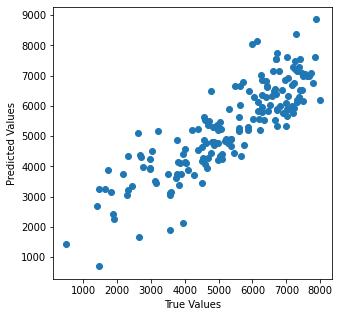

In [11]:
import matplotlib.pyplot as plt

n_train = len(df_train['mb'])
n_test  = len(df_test['mb'])

mu_train = glm_bike.predict(df_train)
y_train  = df_train['mb']

plt.figure(figsize=(5, 5))
plt.scatter(y_train, mu_train)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

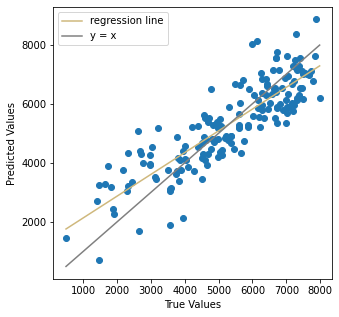

In [12]:
import matplotlib.pyplot as plt
import numpy as np

n_train = len(df_train['mb'])
n_test  = len(df_test['mb'])

mu_train = glm_bike.predict(df_train)
y_train  = df_train['mb']

plt.figure(figsize=(5, 5))
plt.scatter(y_train, mu_train)

# regression line
m, b = np.polyfit(y_train, mu_train, 1)
x_line = np.linspace(y_train.min(), y_train.max(), 100)
plt.plot(x_line, m * x_line + b, color='#CFB87C', label='regression line')

# y = x line
plt.plot(x_line, x_line, color='grey', label='y = x')

plt.legend()
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

The same plot on the test set shows a bit more variability, further suggesting that the model fit is less than optimal.

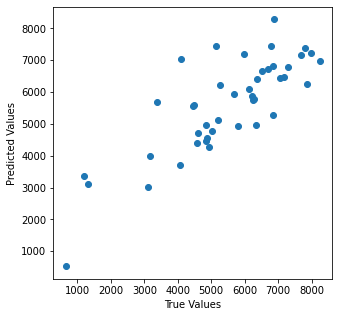

In [13]:
n_train = len(df_train['mb'])
n_test  = len(df_test['mb'])

mu_test = glm_bike.predict(df_test)
y_test  = df_test['mb']

plt.figure(figsize=(5, 5))
plt.scatter(y_test, mu_test)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

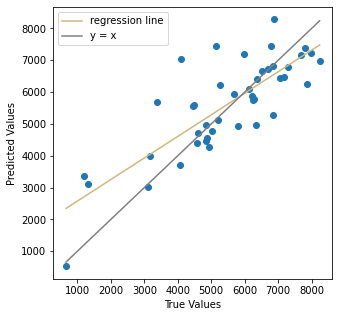

In [14]:
n_train = len(df_train['mb'])
n_test  = len(df_test['mb'])

mu_test = glm_bike.predict(df_test)
y_test  = df_test['mb']

plt.figure(figsize=(5, 5))
plt.scatter(y_test, mu_test)

# regression line
m, b = np.polyfit(y_test, mu_test, 1)
x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, m * x_line + b, color='#CFB87C', label='regression line')

# y = x line
plt.plot(x_line, x_line, color='grey', label='y = x')

plt.legend()
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()